 RISK SIGNAL: Yield Curve Inversion detected on Jun 2024! (2Y: 7.2% > 10Y: 7.12%)


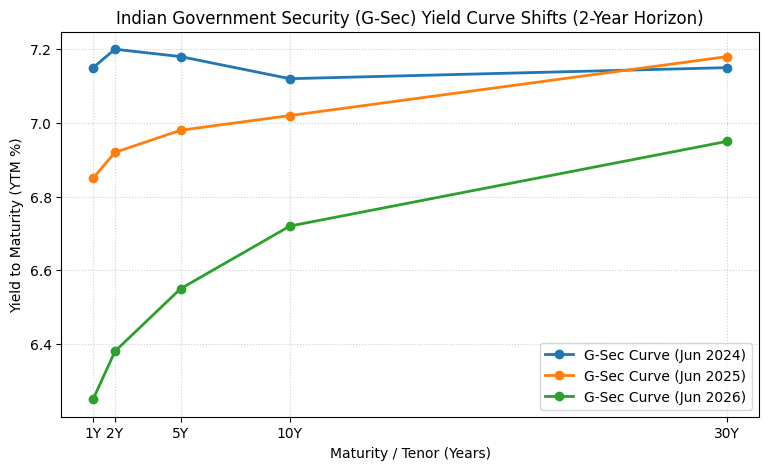

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df_yields = pd.read_csv('gsec_yields.csv')
df_yields['Date'] = pd.to_datetime(df_yields['Date'])
maturities = np.array([1, 2, 5, 10, 30])
tenor_labels = ['1Y', '2Y', '5Y', '10Y', '30Y']
plt.figure(figsize=(9, 5))
for idx, row in df_yields.iterrows():
    yield_values = row[tenor_labels].values.astype(float)
    date_str = row['Date'].strftime('%b %Y')
    plt.plot(maturities, yield_values, marker='o', lw=2, label=f'G-Sec Curve ({date_str})')
    if yield_values[1] > yield_values[3]:
        print(f" RISK SIGNAL: Yield Curve Inversion detected on {date_str}! (2Y: {yield_values[1]}% > 10Y: {yield_values[3]}%)")

plt.title('Indian Government Security (G-Sec) Yield Curve Shifts (2-Year Horizon)')
plt.xlabel('Maturity / Tenor (Years)')
plt.ylabel('Yield to Maturity (YTM %)')
plt.xticks(maturities, tenor_labels)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()
portfolio = [
    {"Bond": "G-Sec 1Y", "Maturity": 1, "Coupon_Rate": 0.065, "YTM": df_yields.loc[2, '1Y']/100, "Notional": 50_000_000},
    {"Bond": "G-Sec 5Y", "Maturity": 5, "Coupon_Rate": 0.068, "YTM": df_yields.loc[2, '5Y']/100, "Notional": 100_000_000},
    {"Bond": "G-Sec 10Y", "Maturity": 10, "Coupon_Rate": 0.070, "YTM": df_yields.loc[2, '10Y']/100, "Notional": 100_000_000},
    {"Bond": "G-Sec 30Y", "Maturity": 30, "Coupon_Rate": 0.072, "YTM": df_yields.loc[2, '30Y']/100, "Notional": 50_000_000}]
def calculate_bond_metrics(face_value, coupon_rate, ytm, maturity, frequency=2):
    """Calculates Price, Macaulay/Modified Duration, Convexity, and DV01 via cash flow vectors."""
    tot_periods = int(maturity * frequency)
    coupon_payment = (coupon_rate / frequency) * face_value
    r_per_period = ytm / frequency
    times = np.arange(1, tot_periods + 1) / frequency
    cash_flows = np.repeat(coupon_payment, tot_periods)
    cash_flows[-1] += face_value 
    pv_factors = 1 / (1 + r_per_period) ** (times * frequency)
    pv_cash_flows = cash_flows * pv_factors
    bond_price = np.sum(pv_cash_flows)
    macaulay_duration = np.sum(times * pv_cash_flows) / bond_price
    modified_duration = macaulay_duration / (1 + r_per_period)
    convexity = np.sum((times * (times + 1/frequency)) * pv_cash_flows) / (bond_price * (1 + r_per_period)**2)
    dv01 = bond_price * modified_duration * 0.0001
    return bond_price, macaulay_duration, modified_duration, convexity, dv01
results_record = []
for bond in portfolio:
    price, mac_dur, mod_dur, conv, dv01 = calculate_bond_metrics(
        face_value=bond["Notional"], 
        coupon_rate=bond["Coupon_Rate"], 
        ytm=bond["YTM"], 
        maturity=bond["Maturity"]
    )
    results_record.append({
        "Asset Description": bond["Bond"],
        "Notional Value (INR)": f"{bond['Notional']:,}",
        "Current Market Value": round(price, 2),
        "Macaulay Duration (Yrs)": round(mac_dur, 3),
        "Modified Duration (Yrs)": round(mod_dur, 3),
        "Convexity Measure": round(conv, 3),
        "DV01 Risk Profile (INR)": round(dv01, 2) })




In [5]:
df_portfolio_risk = pd.DataFrame(results_record)
print(" RISK AND SENSITIVITY SCORECARD " )
print(df_portfolio_risk.to_string(index=False))

 RISK AND SENSITIVITY SCORECARD 
Asset Description Notional Value (INR)  Current Market Value  Macaulay Duration (Yrs)  Modified Duration (Yrs)  Convexity Measure  DV01 Risk Profile (INR)
         G-Sec 1Y           50,000,000           50119375.57                    0.984                    0.954              1.381                  4783.66
         G-Sec 5Y          100,000,000          101051465.76                    4.326                    4.188             21.196                 42325.10
        G-Sec 10Y          100,000,000          102015179.57                    7.385                    7.145             64.826                 72887.93
        G-Sec 30Y           50,000,000           51566928.86                   12.895                   12.462            250.581                 64260.17
